In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np

dfa = pd.read_parquet(r'C:\Users\irees\Downloads\Summer_learning\research26\Brazil_22_lvl0\scintpi3_20221004_2000_359060.7812W_72122.4141S_v325_lvl0.pq')
dfb = pd.read_parquet(r'C:\Users\irees\Downloads\Summer_learning\research26\Brazil_22_lvl0\scintpi3_20221004_2000_359072.7500W_72126.9375S_v325_lvl0.pq')
display(dfa.head())
dfb.head()

dfb.sample(n = 10)

,leap,cons,svid,elev,azim,snr1,snr2,snr3,pst3,rst3,cph1,cph2,cph3,rng1,rng2,rng3,lon,lat,hei,datetime
0,18,0,31,6,279,41,35,0,0,0,1.291349e+08,1.006247e+08,0.0,2.457355e+07,2.457357e+07,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250
1,18,0,12,29,23,43,40,0,0,0,1.178793e+08,9.185398e+07,0.0,2.243167e+07,2.243168e+07,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250
2,18,0,2,16,141,40,0,0,0,0,1.233021e+08,0.000000e+00,0.0,2.346360e+07,0.000000e+00,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250
3,18,0,15,36,92,44,42,0,0,0,1.169097e+08,9.109848e+07,0.0,2.224718e+07,2.224719e+07,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250
4,18,0,23,66,297,46,47,0,0,0,1.064099e+08,8.291676e+07,0.0,2.024909e+07,2.024910e+07,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250


,leap,cons,svid,elev,azim,snr1,snr2,snr3,pst3,rst3,cph1,cph2,cph3,rng1,rng2,rng3,lon,lat,hei,datetime
2730355,18,2,3,12,337,36,41,0,0,0,1.621707e+08,1.242607e+08,0.0,3.086004e+07,3.086006e+07,0.0,-359072.59375,-72126.773438,538.197021,2022-10-04 20:59:54.062500
1467465,18,3,20,70,123,51,0,0,0,0,1.243143e+08,0.000000e+00,0.0,2.387322e+07,0.000000e+00,0.0,-359072.62500,-72126.890625,546.249023,2022-10-04 20:32:09.203125
1525474,18,0,18,30,191,44,42,0,0,0,1.317475e+08,1.026605e+08,0.0,2.507070e+07,2.507070e+07,0.0,-359072.62500,-72126.898438,546.215027,2022-10-04 20:33:25.109375
619755,18,2,9,43,78,46,50,0,0,0,1.408322e+08,1.079103e+08,0.0,2.679946e+07,2.679947e+07,0.0,-359072.65625,-72126.914062,546.591003,2022-10-04 20:13:52.406250
6095088,18,2,5,76,72,48,52,0,0,0,1.177194e+08,9.020070e+07,0.0,2.240122e+07,2.240123e+07,0.0,-359072.96875,-72126.507812,540.921997,2022-10-04 22:14:08.593750
3796903,18,6,6,54,339,41,0,0,0,0,9.367688e+07,0.000000e+00,0.0,1.755499e+07,0.000000e+00,0.0,-359072.68750,-72126.671875,539.289001,2022-10-04 21:24:04.093750
7730438,18,3,30,28,54,46,0,0,0,0,1.275670e+08,0.000000e+00,0.0,2.449791e+07,0.000000e+00,0.0,-359072.90625,-72126.609375,535.408020,2022-10-04 22:51:26.156250
6164155,18,0,10,48,221,48,46,0,0,0,1.067385e+08,8.317303e+07,0.0,2.031166e+07,2.031167e+07,0.0,-359072.96875,-72126.515625,541.164978,2022-10-04 22:15:41.953125
4353568,18,2,36,31,163,44,46,0,0,0,1.250565e+08,9.582262e+07,0.0,2.379743e+07,2.379744e+07,0.0,-359072.71875,-72126.625000,538.674988,2022-10-04 21:36:27.796875
9050913,18,2,2,22,329,41,46,0,0,0,1.448041e+08,1.109540e+08,0.0,2.755526e+07,2.755526e+07,0.0,-359073.53125,-72127.218750,529.351013,2022-10-04 23:22:22.046875


In [2]:
#cut down dfs
dfa = dfa[dfa['elev'] > 20]

df_suba = dfa[['svid', 'snr1']]

dfb = dfb[dfb['elev'] > 20]

df_subb = dfb[['svid', 'snr1']]


In [3]:
#method 2 calculating distance
#haversine formula : computes great circle distance follows earths curvature

dfa['deg_lon'] = dfa['lon']/10000
dfa['deg_lat'] = dfa['lat']/10000
dfb['deg_lon'] = dfb['lon']/10000
dfb['deg_lat'] = dfb['lat']/10000


display(dfb)
def haversine(lon1, lat1, lon2, lat2):
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    R = 6371 #km


    lamba = lon2 - lon1
    deta = lat2 - lat1

    a = (np.sin(deta/2))**2 + np.cos(lon1)*np.cos(lon2)*(np.sin(lamba/2))**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    d = R * c
    
    return(d)

distances = haversine(dfa['deg_lon'].iloc[0], dfa['deg_lat'].iloc[0], dfb['deg_lon'].iloc[0], dfb['deg_lat'].iloc[0])
dist = np.mean(distances)

print(f'{dist} km')

#3D distance now using pythagorean theorem and curvature haversine distance
heights = (dfb['hei'] - dfa['hei'])/1000

distance_3d = np.sqrt(distances**2 + heights**2)
dist_3d = np.mean(distance_3d)

print(f'{dist_3d} km')





,leap,cons,svid,elev,azim,snr1,snr2,snr3,pst3,rst3,...,cph3,rng1,rng2,rng3,lon,lat,hei,datetime,deg_lon,deg_lat
0,18,0,15,36,92,46,42,0,0,0,...,0.0,2.389248e+07,2.389249e+07,0.0,-359072.750,-72126.93750,543.103027,2022-10-04 20:00:18.203125,-35.907276,-7.212694
2,18,0,12,29,23,43,39,0,0,0,...,0.0,2.407692e+07,2.407693e+07,0.0,-359072.750,-72126.93750,543.103027,2022-10-04 20:00:18.203125,-35.907276,-7.212694
3,18,0,29,45,152,46,42,0,0,0,...,0.0,2.321644e+07,2.321644e+07,0.0,-359072.750,-72126.93750,543.103027,2022-10-04 20:00:18.203125,-35.907276,-7.212694
4,18,0,18,33,207,43,43,0,0,0,...,0.0,2.387900e+07,2.387901e+07,0.0,-359072.750,-72126.93750,543.103027,2022-10-04 20:00:18.203125,-35.907276,-7.212694
6,18,3,32,26,136,43,0,0,0,0,...,0.0,2.609993e+07,0.000000e+00,0.0,-359072.750,-72126.93750,543.103027,2022-10-04 20:00:18.203125,-35.907276,-7.212694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10588362,18,6,7,49,249,50,49,0,0,0,...,0.0,2.237133e+07,2.237133e+07,0.0,-359073.375,-72126.96875,543.125000,2022-10-04 23:59:30.250000,-35.907337,-7.212697
10588364,18,1,136,42,82,45,0,0,0,0,...,0.0,3.972131e+07,0.000000e+00,0.0,-359073.375,-72126.96875,543.125000,2022-10-04 23:59:30.250000,-35.907337,-7.212697
10588366,18,2,5,48,159,44,51,0,0,0,...,0.0,2.673729e+07,2.673729e+07,0.0,-359073.375,-72126.96875,543.125000,2022-10-04 23:59:30.250000,-35.907337,-7.212697
10588367,18,2,34,46,175,48,56,0,0,0,...,0.0,2.680119e+07,2.680120e+07,0.0,-359073.375,-72126.96875,543.125000,2022-10-04 23:59:30.250000,-35.907337,-7.212697


0.11883120238780975 km
0.11991374837680038 km


In [4]:
# #compute seperation between 2 recievers
# # display(dfa[['lon', 'lat', 'hei']])
# # display(dfb[['lon', 'lat', 'hei']])

# #use averages to compute avg pos

# lonA = dfa['lon'].mean()
# latA = dfa['lat'].mean()
# heiA = dfa['hei'].mean()

# print('reciever A positions')
# print(lonA)
# print(latA)
# print(heiA)

# lonB = dfb['lon'].mean()
# latB = dfb['lat'].mean()
# heiB = dfb['hei'].mean()

# print('reciever B positions')
# print(lonB)
# print(latB)
# print(heiB)

# #assuming these are cartesian system positions since they dont follow typical degrees measurements
# #use distance formula to determine distance between them

# d = math.sqrt((lonA - lonB)**2 + (latA - latB)**2 + (heiA - heiB)**2)
# print(f'distance between reciever A and B is {d} (m?)')

In [5]:
merged = dfa.merge(dfb, on=["datetime", "svid", 'cons'], suffixes=("_A", "_B"))


#determine if  signal readings are similar
merged['snr_diff'] = abs(merged['snr1_A'] - merged['snr1_B'])

display(merged)
merged['snr_diff'].describe()

sat15 = merged[(merged['svid'] == 10) & (merged['cons'] == 0)] #change satellite here

sat15["snr_change_A"] = sat15["snr1_A"].diff() #diff helps determine big jump in signal
sat15["snr_change_B"] = sat15["snr1_B"].diff()
display(sat15)
merged['snr_diff'].describe()

,leap_A,cons,svid,elev_A,azim_A,snr1_A,snr2_A,snr3_A,pst3_A,rst3_A,...,cph3_B,rng1_B,rng2_B,rng3_B,lon_B,lat_B,hei_B,deg_lon_B,deg_lat_B,snr_diff
0,18,0,12,29,23,43,40,0,0,0,...,0.0,2.407697e+07,2.407698e+07,0.0,-359072.750,-72126.93750,543.103027,-35.907276,-7.212694,0
1,18,0,15,36,92,44,42,0,0,0,...,0.0,2.389251e+07,2.389251e+07,0.0,-359072.750,-72126.93750,543.103027,-35.907276,-7.212694,254
2,18,0,23,66,297,46,47,0,0,0,...,0.0,2.189428e+07,2.189428e+07,0.0,-359072.750,-72126.93750,543.103027,-35.907276,-7.212694,254
3,18,3,19,39,342,48,0,0,0,0,...,0.0,2.501911e+07,0.000000e+00,0.0,-359072.750,-72126.93750,543.103027,-35.907276,-7.212694,1
4,18,3,20,73,73,51,0,0,0,0,...,0.0,2.284948e+07,0.000000e+00,0.0,-359072.750,-72126.93750,543.103027,-35.907276,-7.212694,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649432,18,0,32,72,173,51,49,0,0,0,...,0.0,2.247284e+07,2.247284e+07,0.0,-359073.375,-72126.96875,543.080017,-35.907337,-7.212697,1
3649433,18,2,34,46,175,49,49,0,0,0,...,0.0,2.680045e+07,2.680045e+07,0.0,-359073.375,-72126.96875,543.080017,-35.907337,-7.212697,2
3649434,18,2,5,48,159,48,52,0,0,0,...,0.0,2.673262e+07,2.673263e+07,0.0,-359073.375,-72126.96875,543.080017,-35.907337,-7.212697,4
3649435,18,2,3,69,284,49,52,0,0,0,...,0.0,2.584658e+07,2.584659e+07,0.0,-359073.375,-72126.96875,543.080017,-35.907337,-7.212697,0


C:\Users\irees\AppData\Local\Temp\ipykernel_30648\3021849086.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sat15["snr_change_A"] = sat15["snr1_A"].diff() #diff helps determine big jump in signal
C:\Users\irees\AppData\Local\Temp\ipykernel_30648\3021849086.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sat15["snr_change_B"] = sat15["snr1_B"].diff()


,leap_A,cons,svid,elev_A,azim_A,snr1_A,snr2_A,snr3_A,pst3_A,rst3_A,...,rng2_B,rng3_B,lon_B,lat_B,hei_B,deg_lon_B,deg_lat_B,snr_diff,snr_change_A,snr_change_B
18,18,0,10,34,316,47,42,0,0,0,...,2.372941e+07,0.0,-359072.75000,-72126.93750,543.103027,-35.907276,-7.212694,1,NaN,NaN
42,18,0,10,34,316,47,43,0,0,0,...,2.372941e+07,0.0,-359072.75000,-72126.93750,543.098999,-35.907276,-7.212694,1,0.0,0.0
66,18,0,10,34,316,47,42,0,0,0,...,2.372940e+07,0.0,-359072.75000,-72126.93750,543.096008,-35.907276,-7.212694,1,0.0,0.0
90,18,0,10,34,316,47,42,0,0,0,...,2.372940e+07,0.0,-359072.75000,-72126.93750,543.096008,-35.907276,-7.212694,1,0.0,0.0
114,18,0,10,34,316,47,42,0,0,0,...,2.372940e+07,0.0,-359072.75000,-72126.93750,543.096985,-35.907276,-7.212694,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649332,18,0,10,27,168,39,40,0,0,0,...,2.504045e+07,0.0,-359073.40625,-72126.96875,543.059021,-35.907341,-7.212697,252,0.0,0.0
3649353,18,0,10,27,168,39,40,0,0,0,...,2.504052e+07,0.0,-359073.40625,-72126.96875,543.064026,-35.907341,-7.212697,252,0.0,0.0
3649374,18,0,10,27,168,38,40,0,0,0,...,2.504056e+07,0.0,-359073.40625,-72126.96875,543.064026,-35.907341,-7.212697,251,255.0,0.0
3649395,18,0,10,27,168,38,40,0,0,0,...,2.504059e+07,0.0,-359073.40625,-72126.96875,543.072998,-35.907341,-7.212697,251,0.0,0.0


count    3.649437e+06
mean     1.001826e+02
std      1.233884e+02
min      0.000000e+00
25%      0.000000e+00
50%      2.000000e+00
75%      2.540000e+02
max      2.550000e+02
Name: snr_diff, dtype: float64

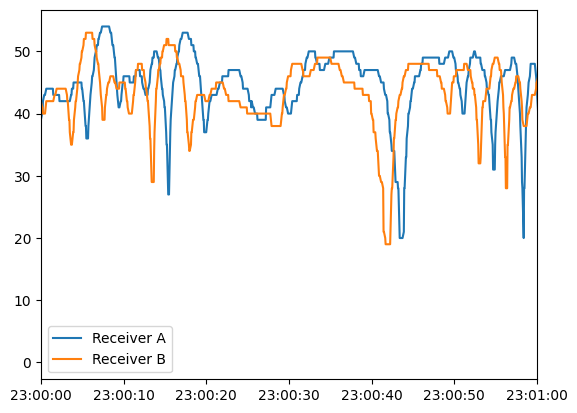

In [6]:
plt.plot(sat15["datetime"], sat15["snr1_A"], label="Receiver A")
plt.plot(sat15["datetime"], sat15["snr1_B"], label="Receiver B")
plt.xlim(
       pd.Timestamp("2022-10-04 23:00:00"),
      pd.Timestamp("2022-10-04 23:01:00")
    )
plt.legend()
plt.show()



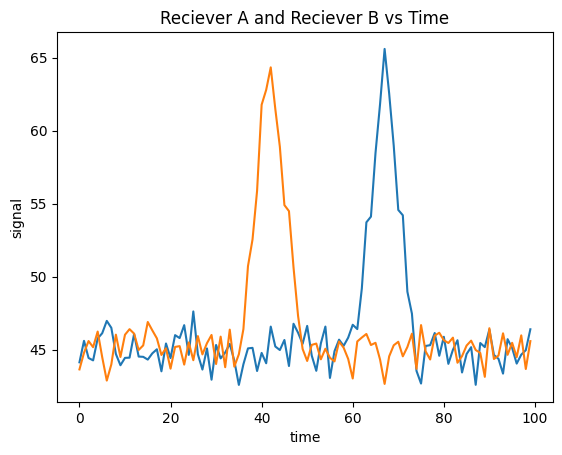

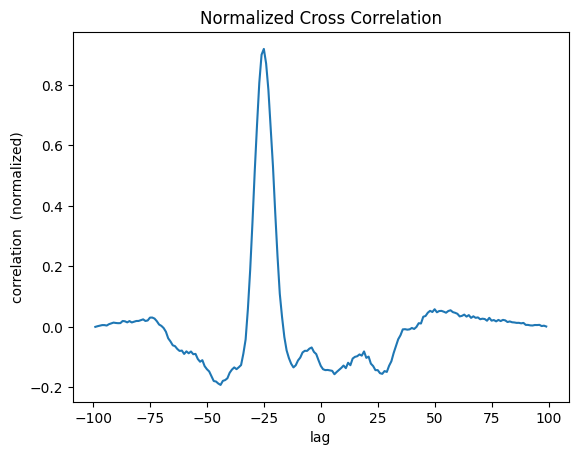

The max correlation is : 0.9185614870548756
The lag is: -25
Error: 11


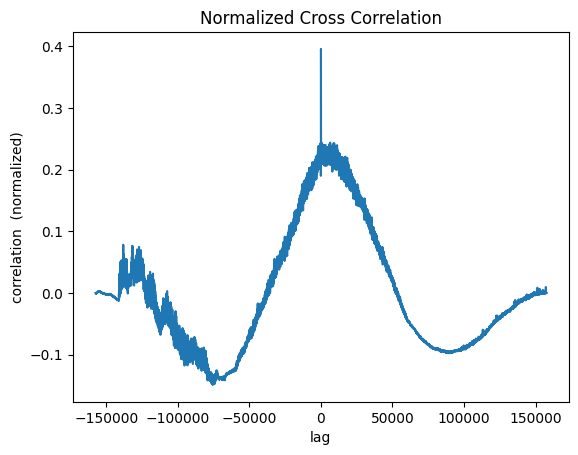

The max correlation is : 0.3955692609141387
The lag is: 35


In [7]:
import importlib
from test_cross_cor import cross_correlation

 #need to normalize time here from datetime to just time
 #function in old code

 #datetime to time
def datetime_to_seconds(df, time_column="datetime"):
    df = df.copy()

    # Seconds since first measurement
    df["time_sec"] = (
        df[time_column] - df[time_column].iloc[0] #simply measure change in time
    ).dt.total_seconds()

    return df

sat15 = datetime_to_seconds(sat15)

correlation, lag_b, cor_norm, lag_norm = cross_correlation(sat15["snr1_A"], sat15["snr1_B"])

print(f'The max correlation is : {correlation}')
print(f'The lag is: {lag_b}')


18          NaN
42     0.046875
66     0.109375
90     0.046875
114    0.046875
138    0.046875
162    0.109375
186    0.046875
210    0.046875
234    0.046875
Name: time_sec, dtype: float64
0.046875
1.640625
0.0730902847249069 km/s


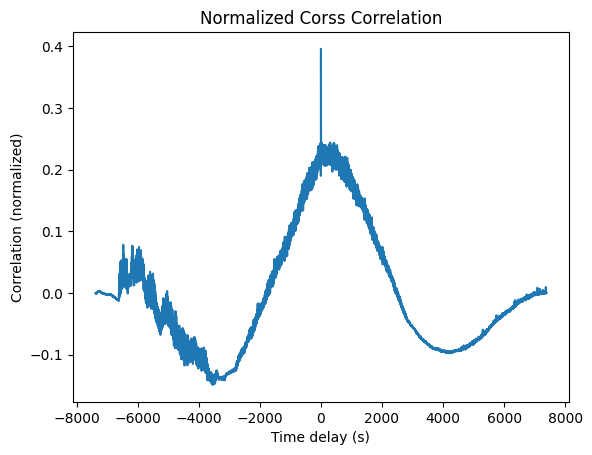

In [8]:
#map index lag to seconds
# print(sat15['datetime'].head(10))
# print(sat15['time_sec'].head(10))
print(sat15["time_sec"].diff().head(10))

print(sat15['time_sec'].diff().median())
#each sample (lag) is this many seconds apart
dt = sat15['time_sec'].diff().median()
time_delay = lag_b * dt #delay between the 2 recievers

print(time_delay)
lag_time = lag_norm * dt
#now with distance and time delay we can compute velocity:
V = dist_3d/time_delay
print(f'{V} km/s')

plt.plot(lag_time, cor_norm)
plt.xlabel('Time delay (s)')
plt.ylabel('Correlation (normalized)')
plt.title('Normalized Corss Correlation')
plt.show()


In [9]:
#calculate s4
#current df is in logarithmic snr measurements need to convert it to linear measurements which is what s4 works in.
#start with just using 1 satelite

import time

def db2lin(sig_db):
    return 10**(sig_db/10)

# #converting log to lin signal
# sig_lin = db2lin(sat15['snr1_A'])
# display(sig_lin)
# s4A = np.std(sig_lin)/np.mean(sig_lin) #run this in each 1 minute window to find if scintillation is in that minute since it produces just 1 value

# display(s4A)



thresh = 0.2
sat15 = datetime_to_seconds(sat15)
#when splitting off of sat15 use groupby to group by specific satellites
min_groups = sat15.groupby(sat15['datetime'].dt.floor('min')) #this last part helps create buckets of data within each minute. may not be specific times but will all be times within the 1 minute frame
#print(min_groups.groups.keys())
scint = []





2022-10-04 20:00:00 has scint


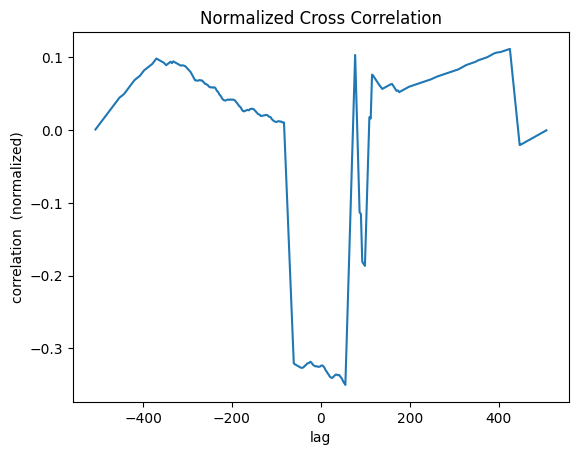

2022-10-04 20:19:00 has scint


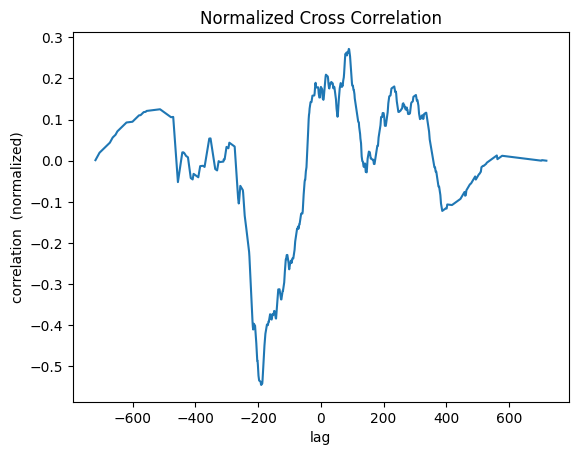

2022-10-04 20:23:00 has scint


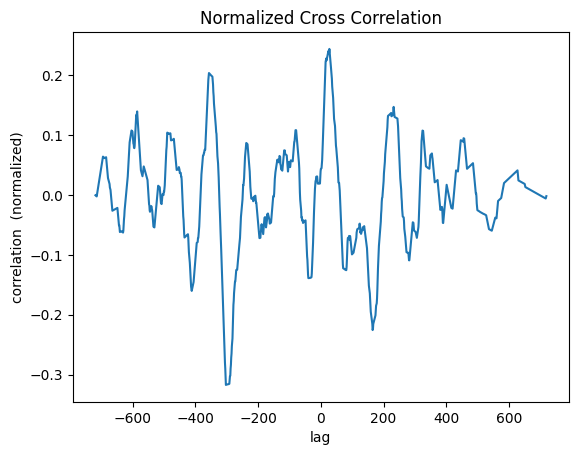

2022-10-04 20:24:00 has scint


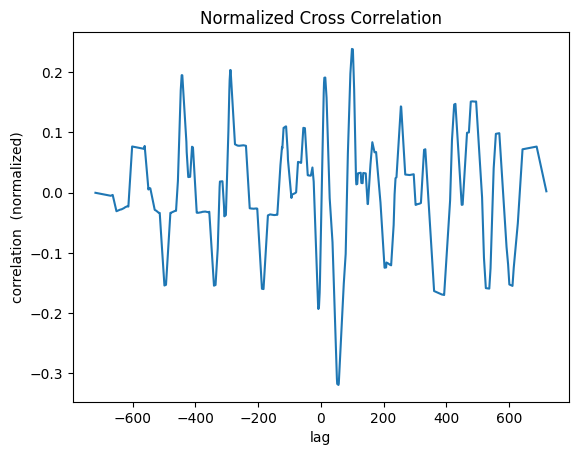

2022-10-04 20:25:00 has scint


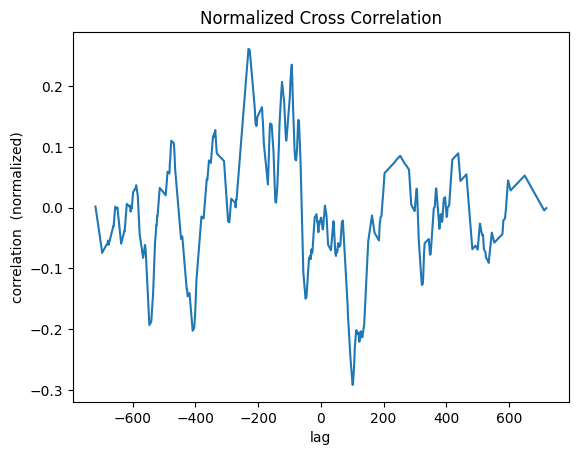

2022-10-04 20:26:00 has scint


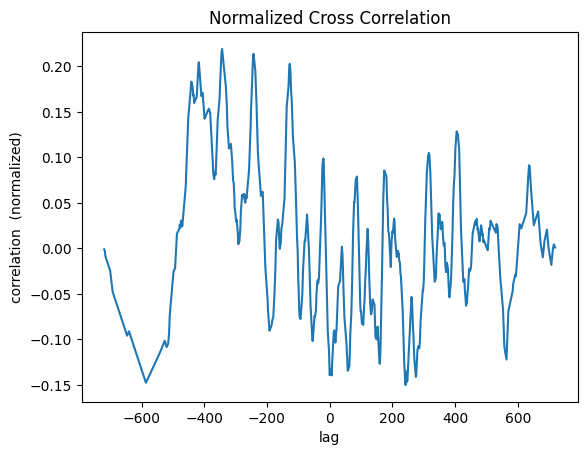

2022-10-04 20:27:00 has scint


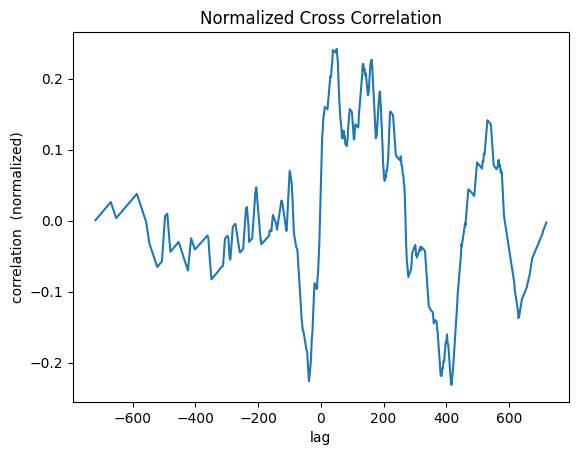

2022-10-04 20:28:00 has scint


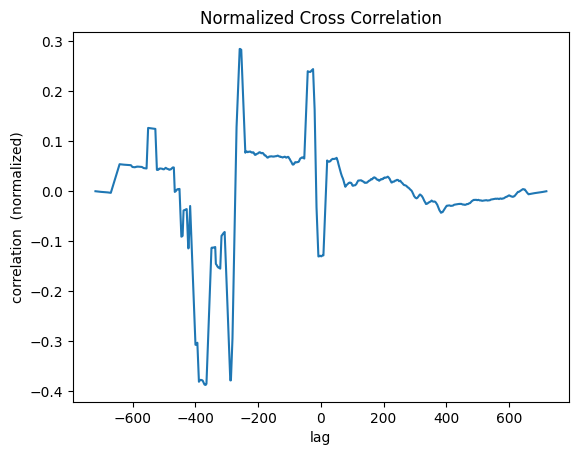

2022-10-04 20:29:00 has scint


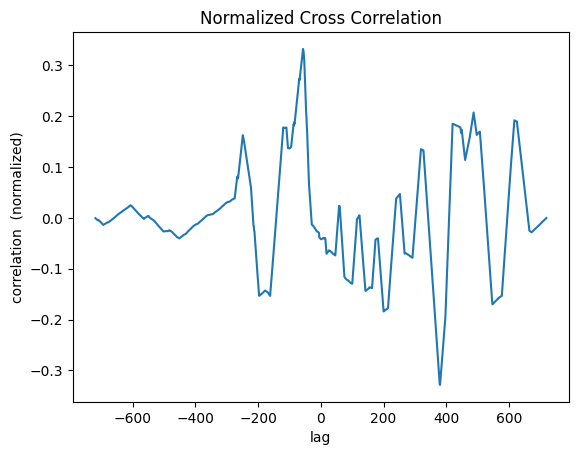

2022-10-04 20:36:00 has scint


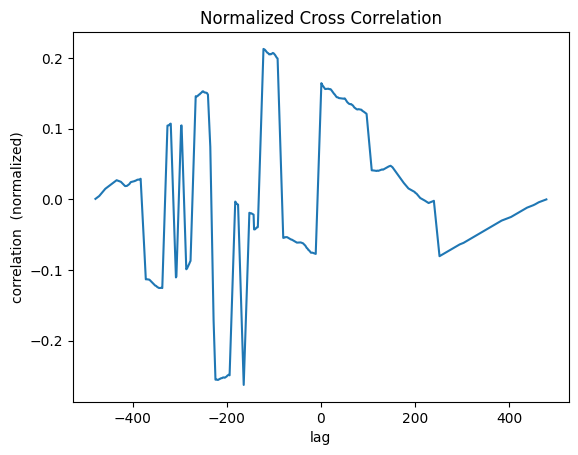

2022-10-04 20:37:00 has scint


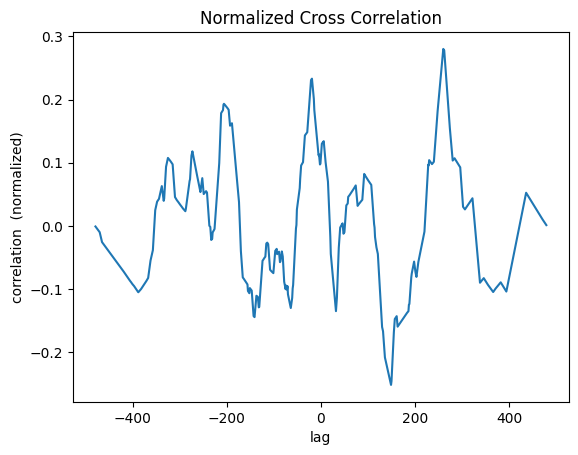

2022-10-04 20:38:00 has scint


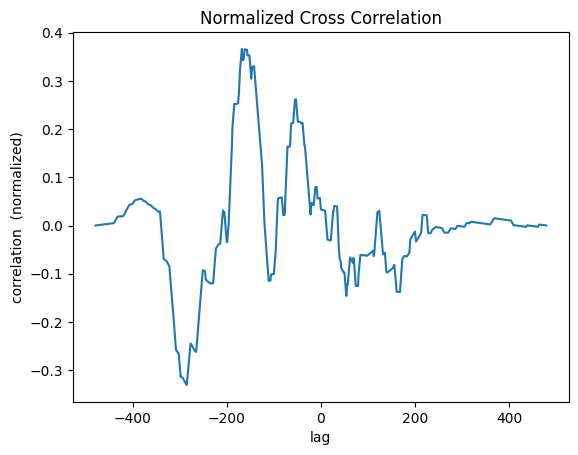

2022-10-04 20:51:00 has scint


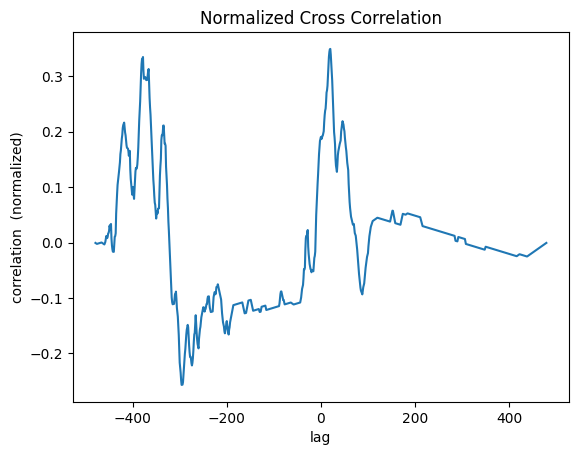

2022-10-04 22:53:00 has scint


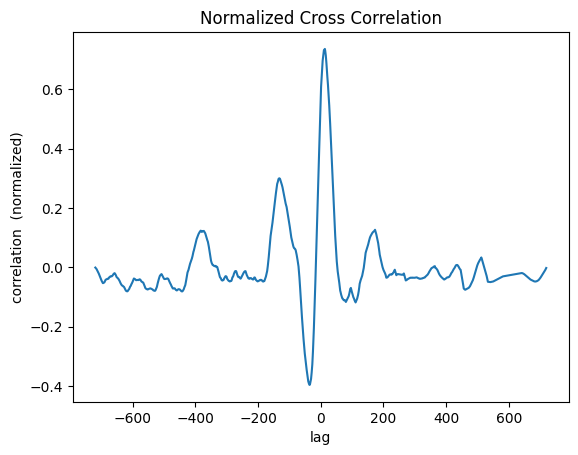

2022-10-04 22:54:00 has scint


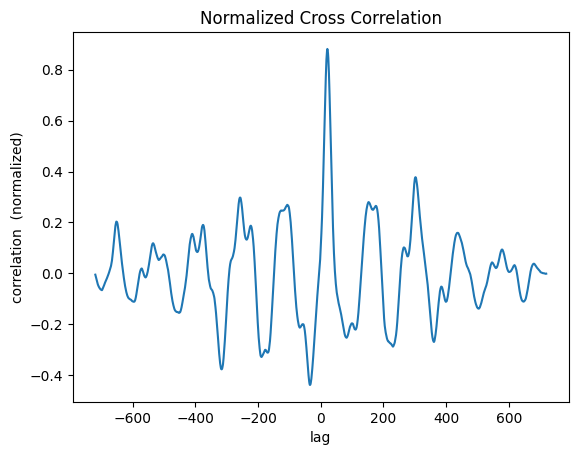

2022-10-04 22:55:00 has scint


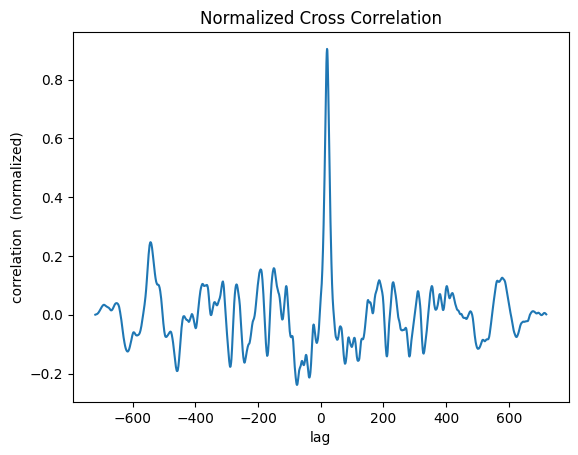

2022-10-04 22:56:00 has scint


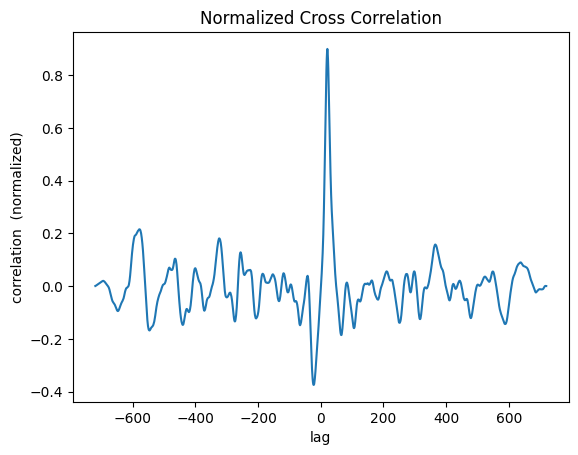

2022-10-04 22:57:00 has scint


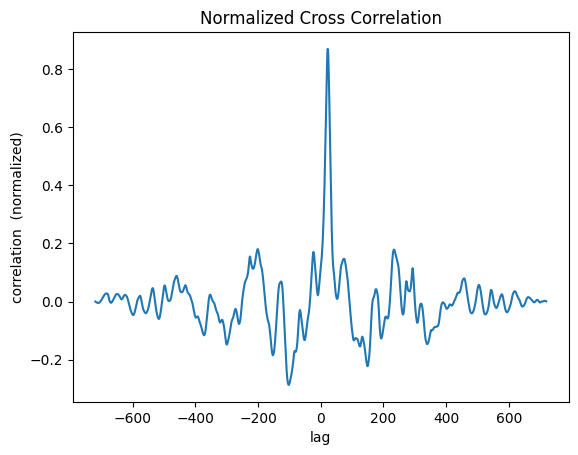

2022-10-04 22:58:00 has scint


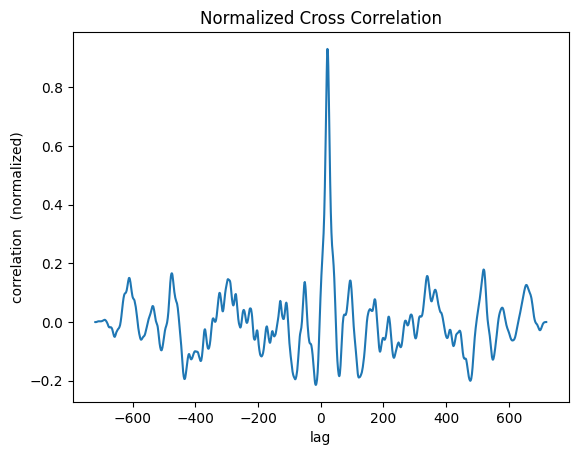

2022-10-04 22:59:00 has scint


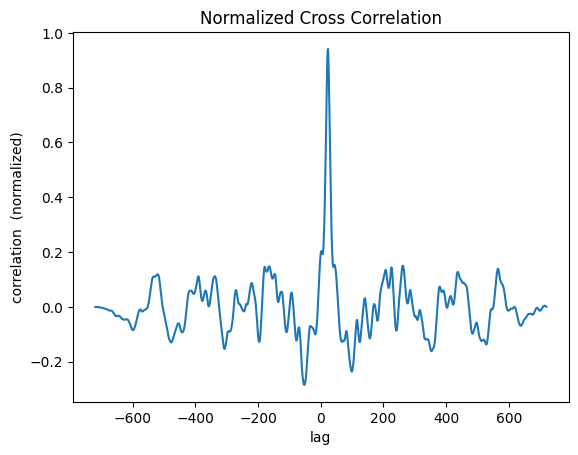

2022-10-04 23:00:00 has scint


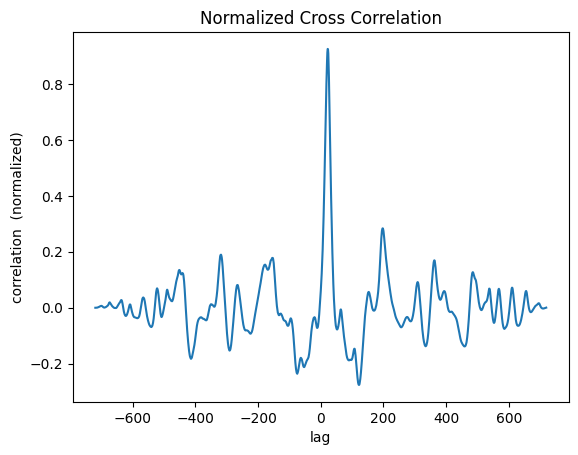

2022-10-04 23:01:00 has scint


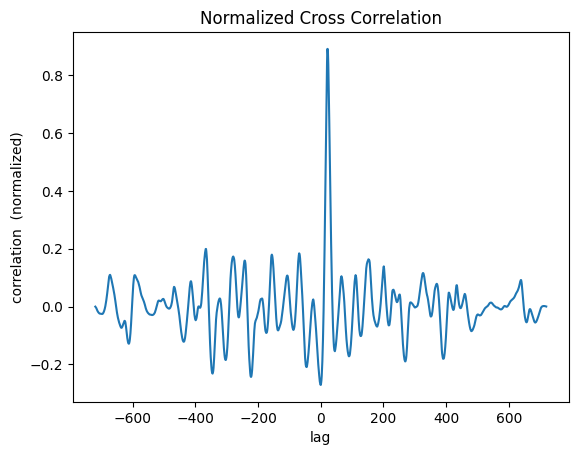

2022-10-04 23:02:00 has scint


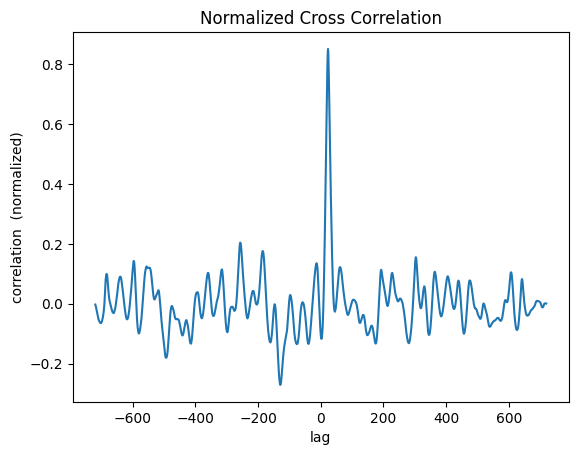

2022-10-04 23:03:00 has scint


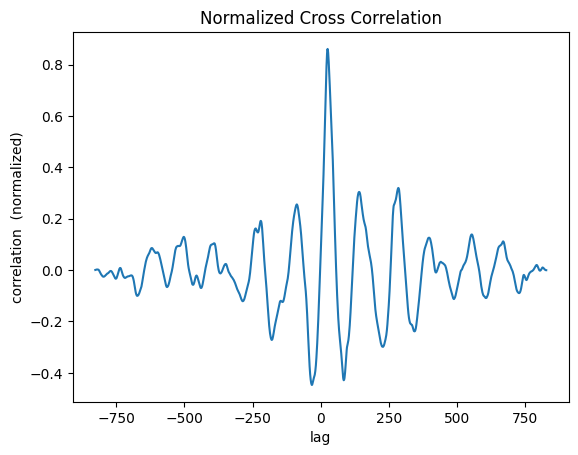

2022-10-04 23:04:00 has scint


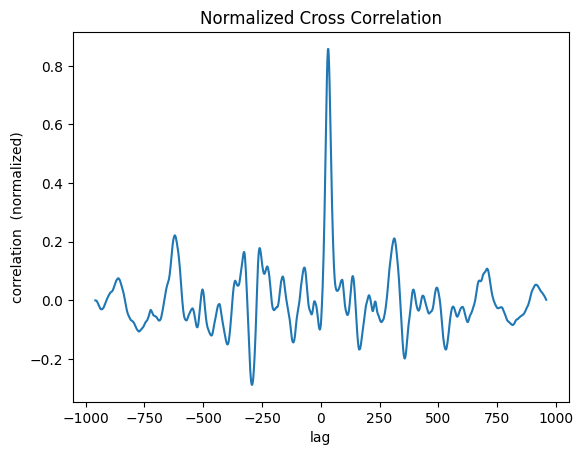

2022-10-04 23:05:00 has scint


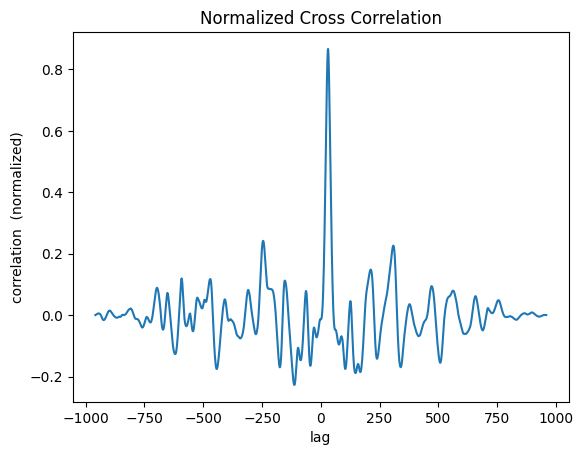

2022-10-04 23:06:00 has scint


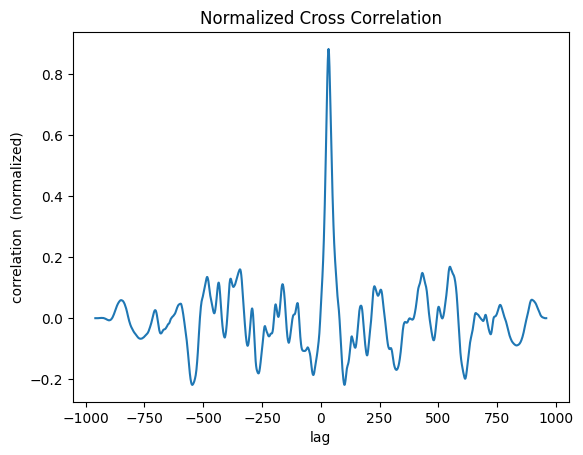

2022-10-04 23:07:00 has scint


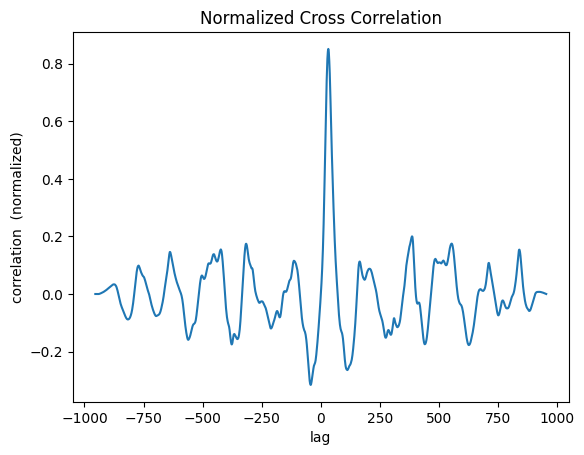

2022-10-04 23:08:00 has scint


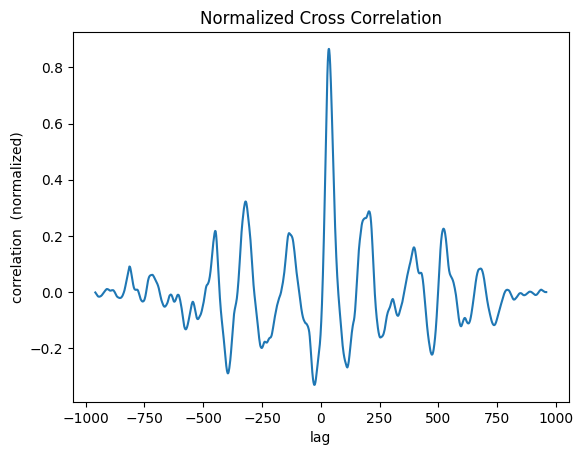

2022-10-04 23:09:00 has scint


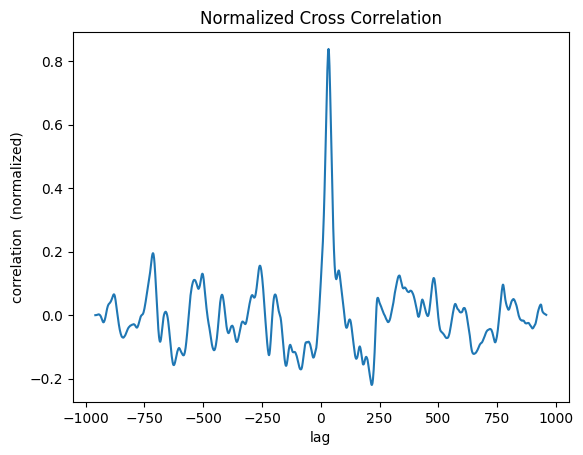

2022-10-04 23:10:00 has scint


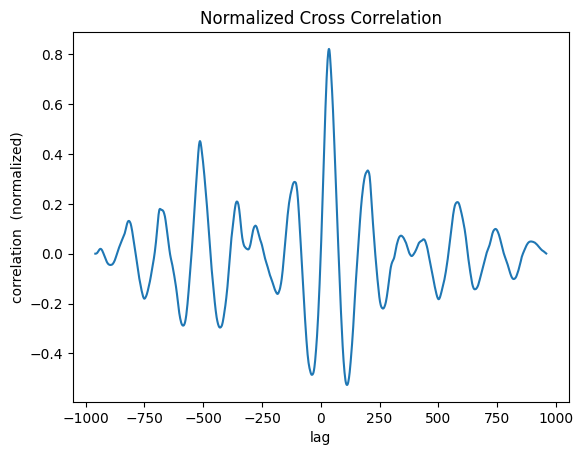

2022-10-04 23:11:00 has scint


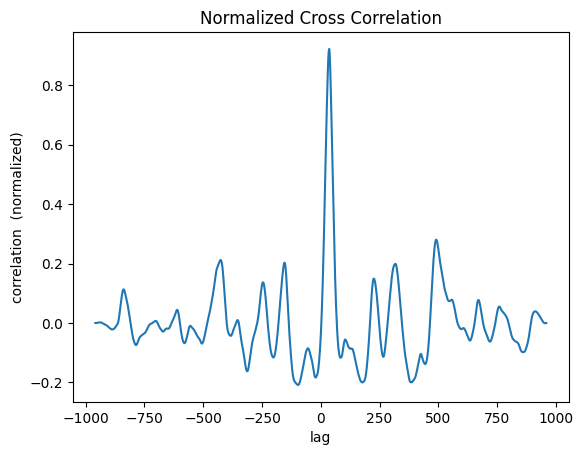

2022-10-04 23:12:00 has scint


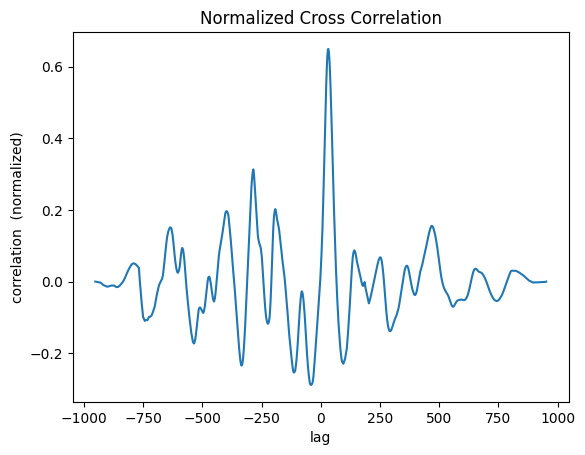

2022-10-04 23:13:00 has scint


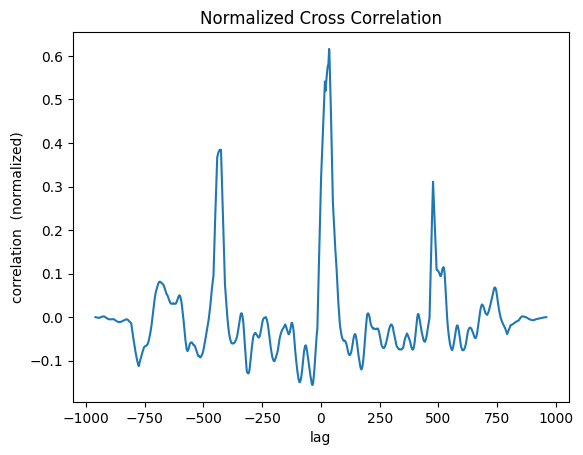

2022-10-04 23:14:00 has scint


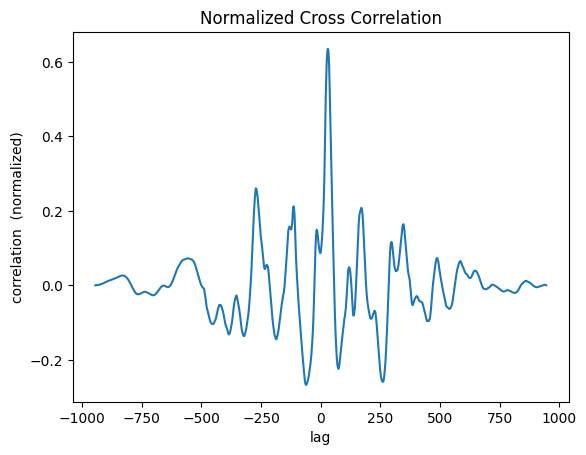

2022-10-04 23:15:00 has scint


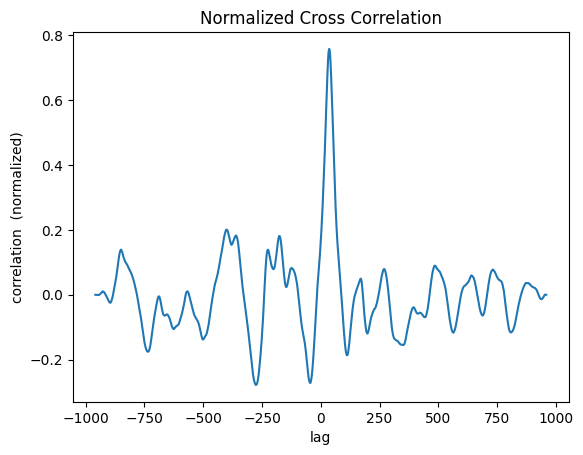

2022-10-04 23:16:00 has scint


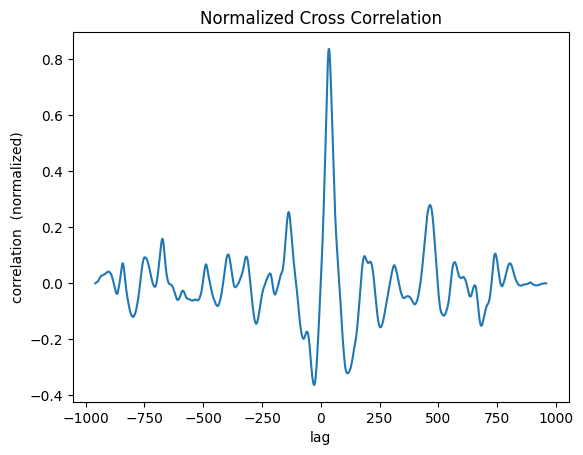

2022-10-04 23:17:00 has scint


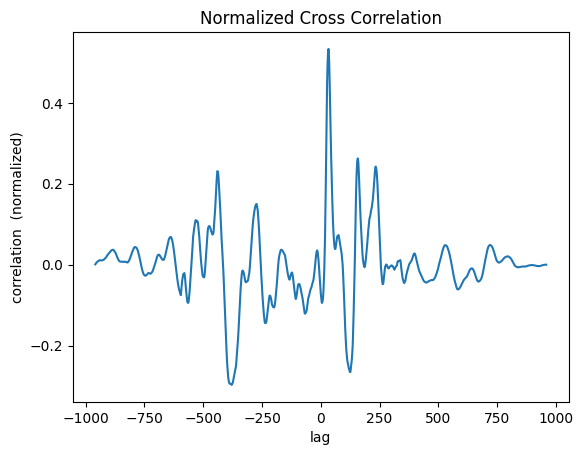

2022-10-04 23:18:00 has scint


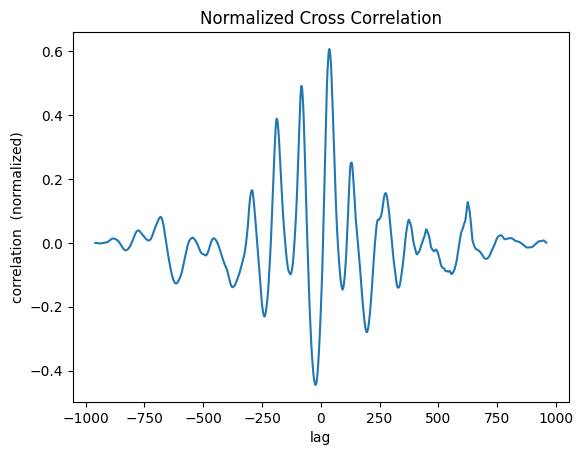

2022-10-04 23:19:00 has scint


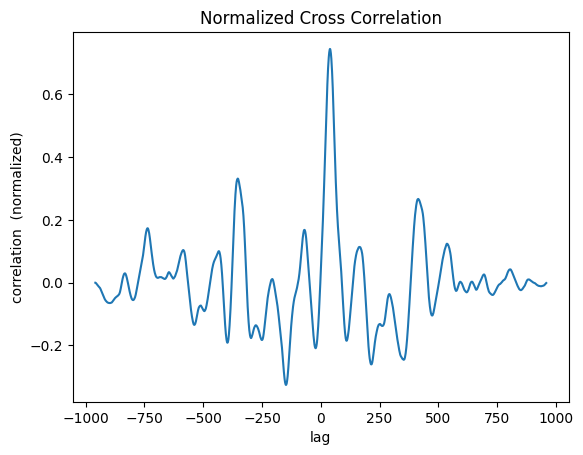

2022-10-04 23:20:00 has scint


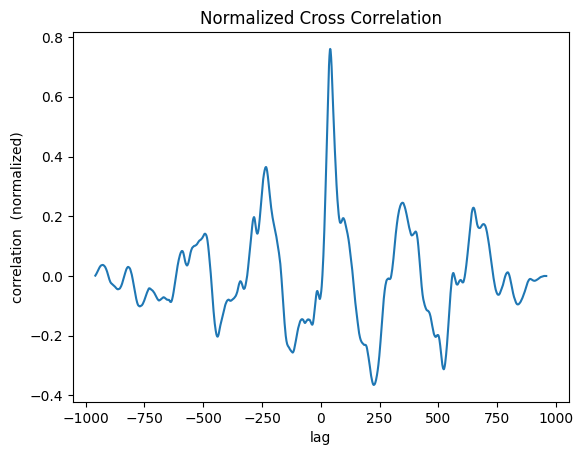

2022-10-04 23:21:00 has scint


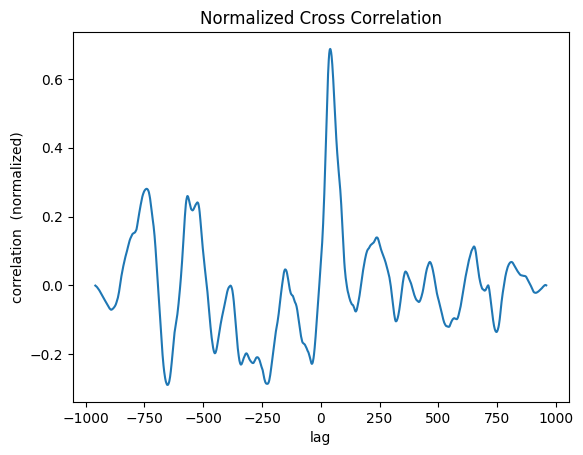

2022-10-04 23:22:00 has scint


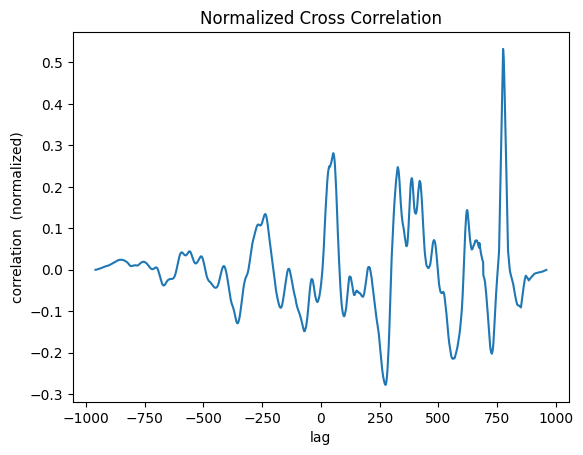

2022-10-04 23:23:00 has scint


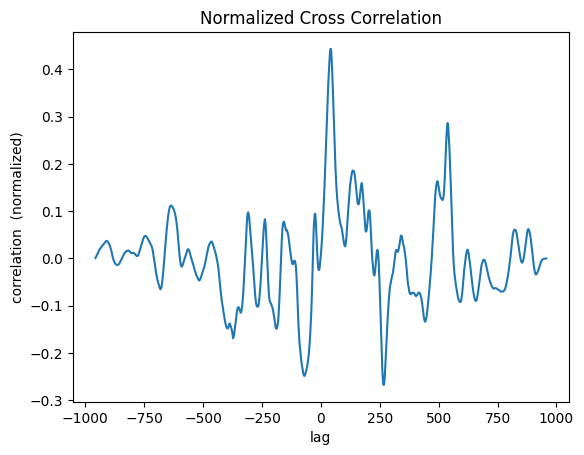

2022-10-04 23:24:00 has scint


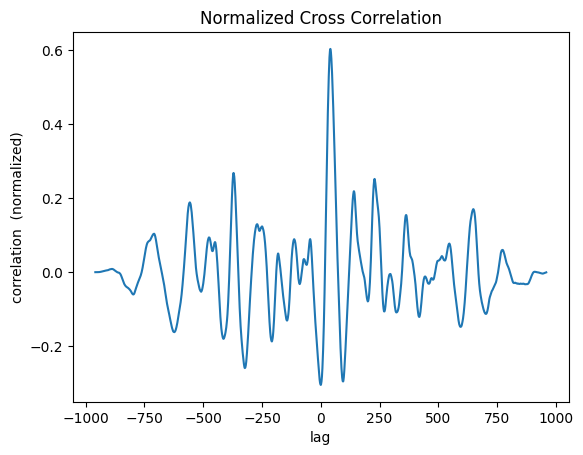

2022-10-04 23:25:00 has scint


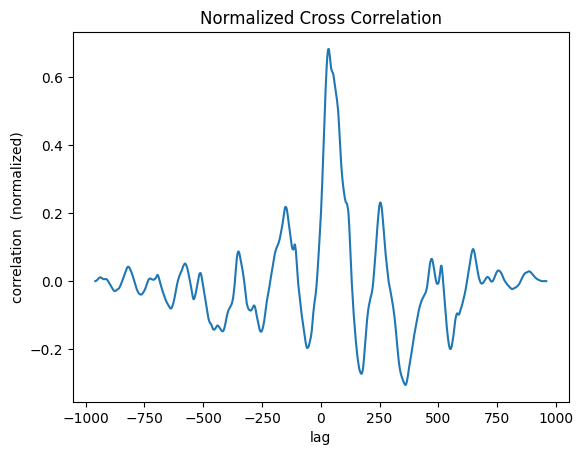

2022-10-04 23:26:00 has scint


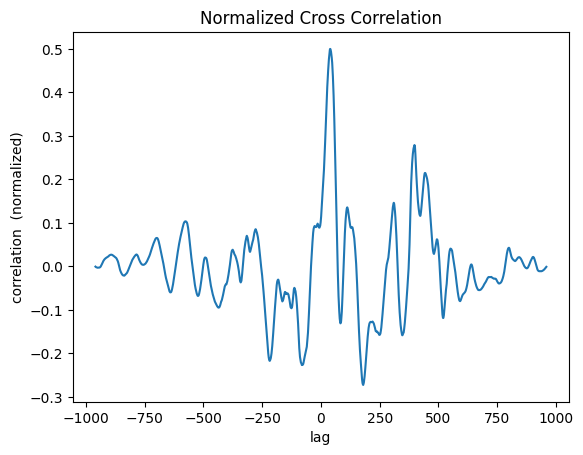

2022-10-04 23:27:00 has scint


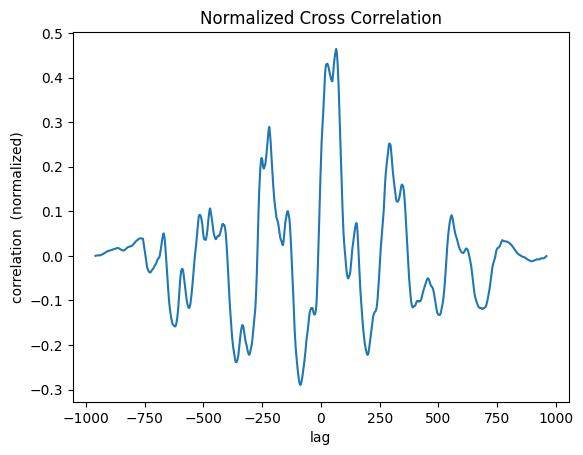

2022-10-04 23:28:00 has scint


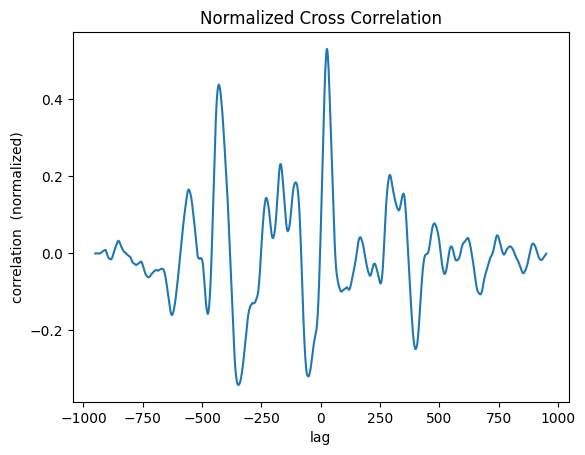

2022-10-04 23:29:00 has scint


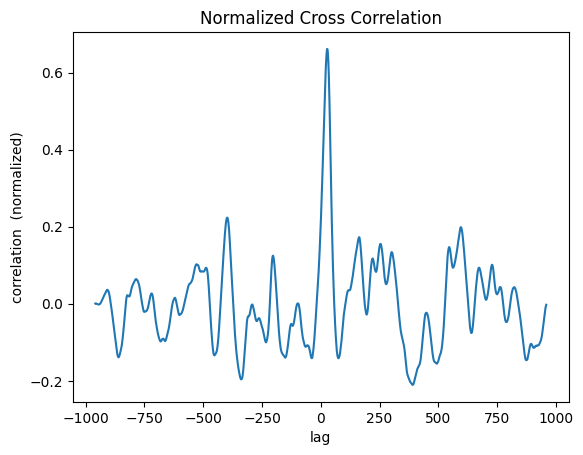

2022-10-04 23:30:00 has scint


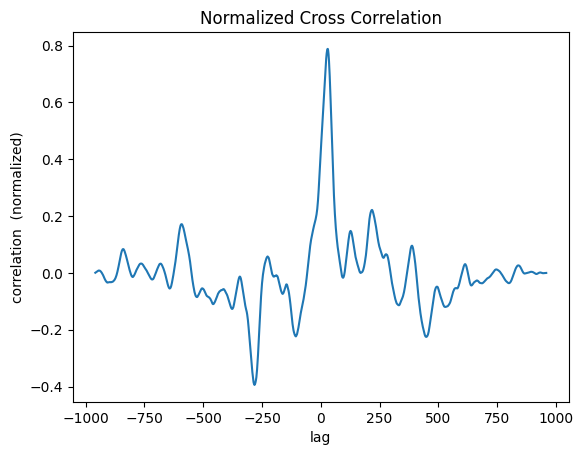

2022-10-04 23:31:00 has scint


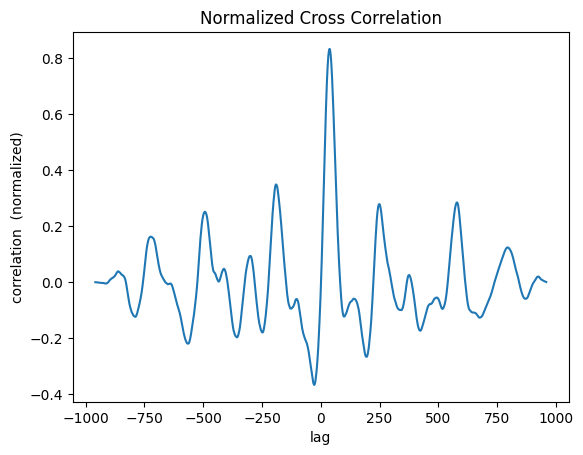

2022-10-04 23:32:00 has scint


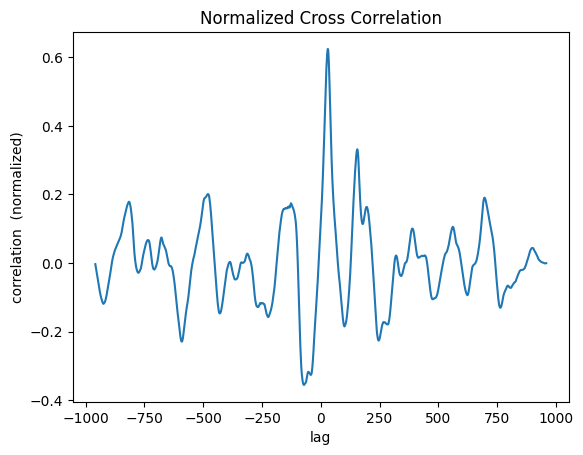

2022-10-04 23:33:00 has scint


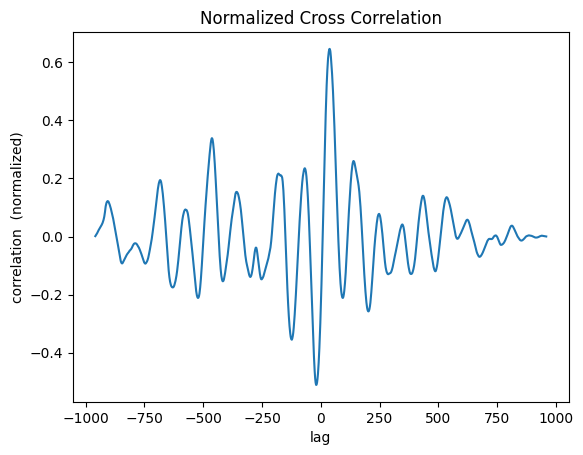

2022-10-04 23:34:00 has scint


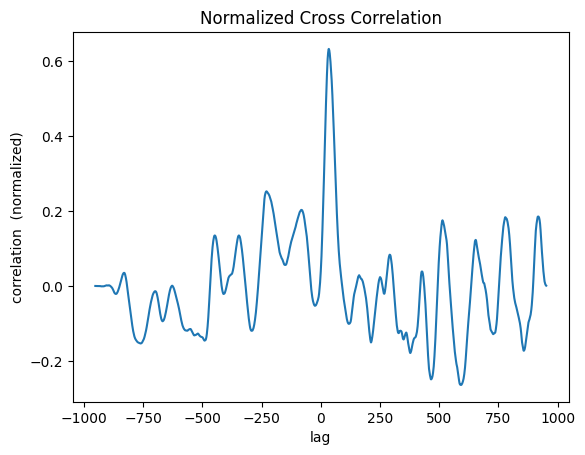

2022-10-04 23:35:00 has scint


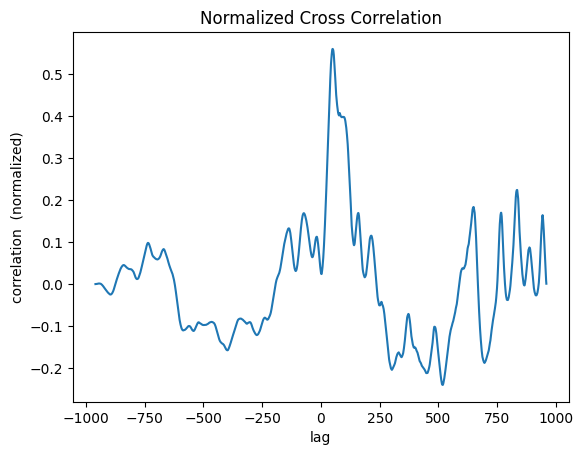

2022-10-04 23:36:00 has scint


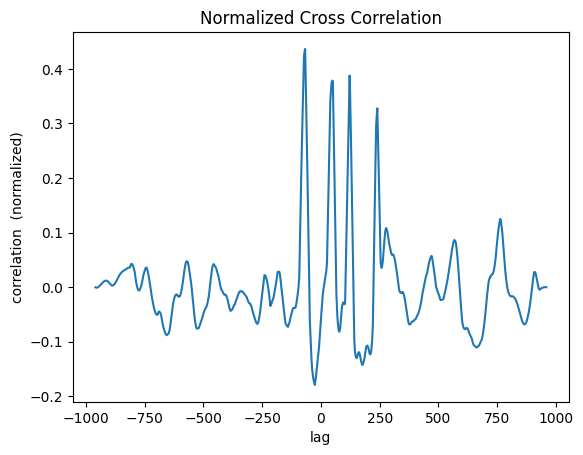

2022-10-04 23:37:00 has scint


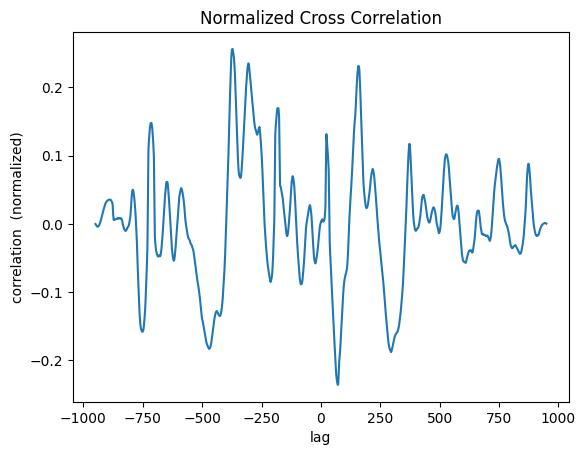

2022-10-04 23:38:00 has scint


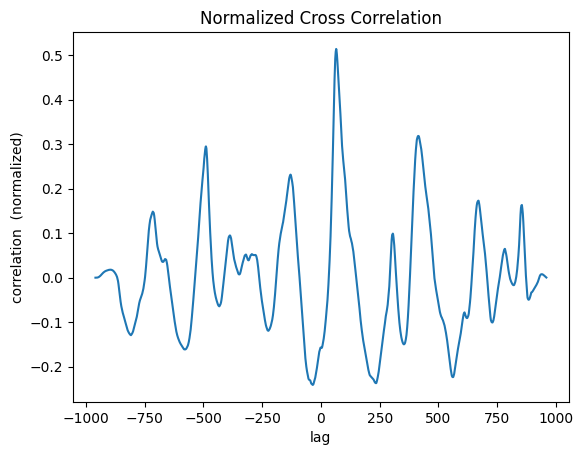

2022-10-04 23:39:00 has scint


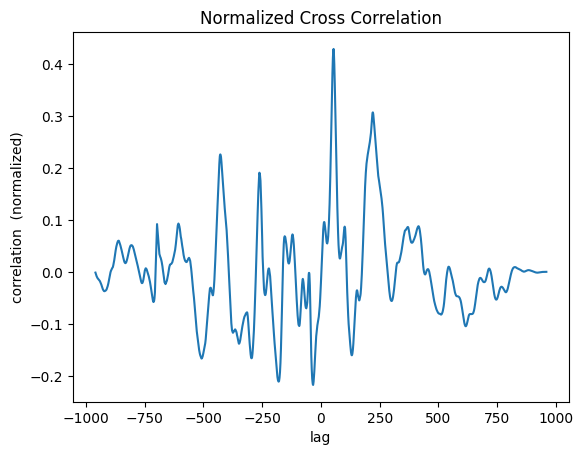

2022-10-04 23:40:00 has scint


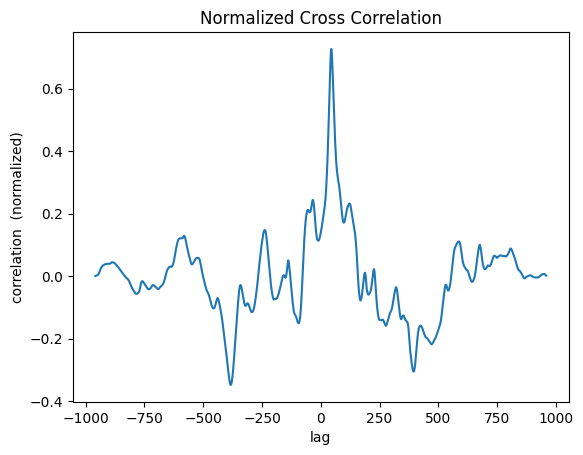

2022-10-04 23:41:00 has scint


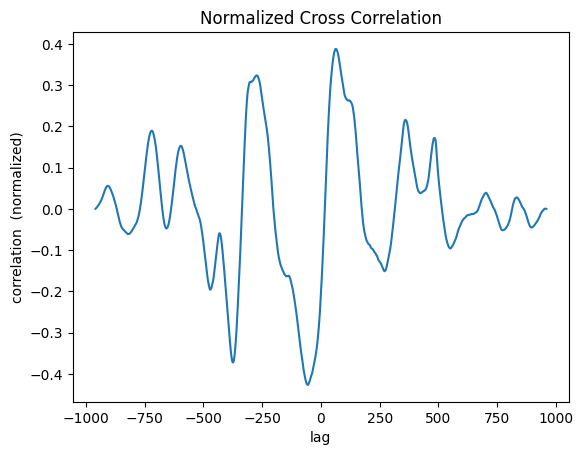

2022-10-04 23:42:00 has scint


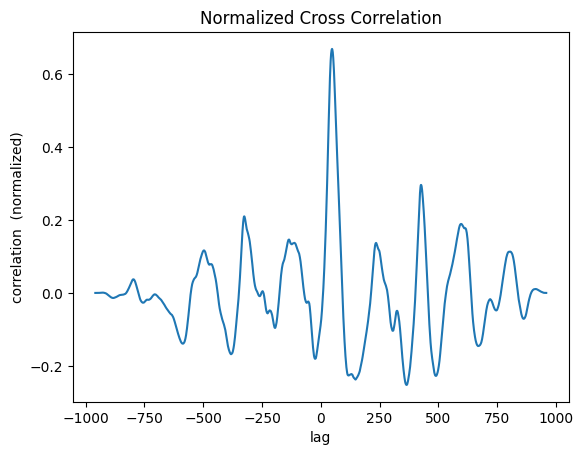

2022-10-04 23:43:00 has scint


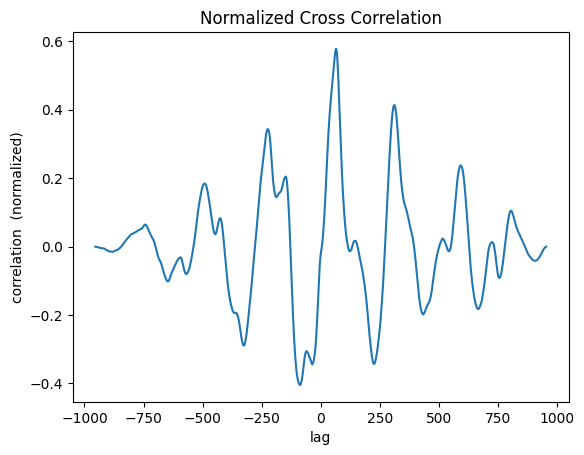

2022-10-04 23:44:00 has scint


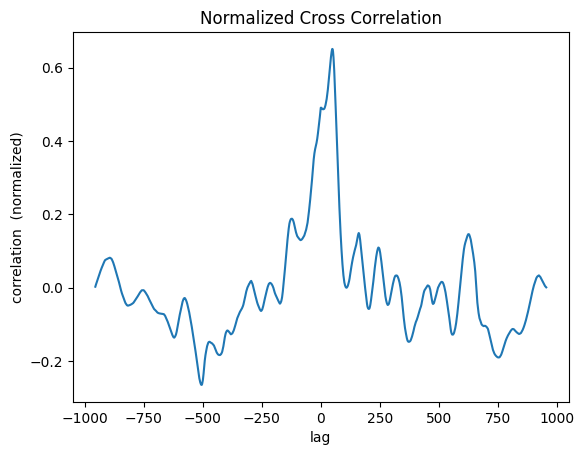

2022-10-04 23:45:00 has scint


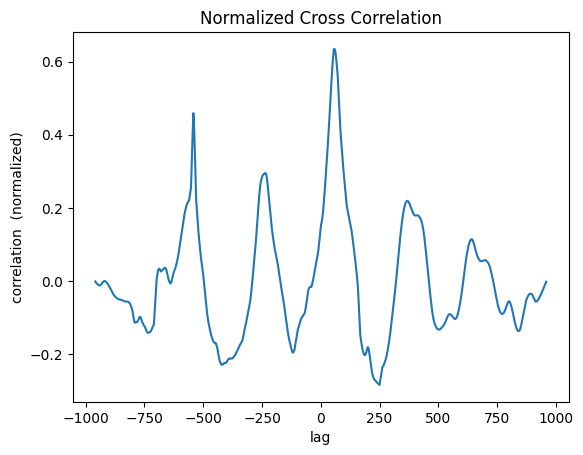

2022-10-04 23:46:00 has scint


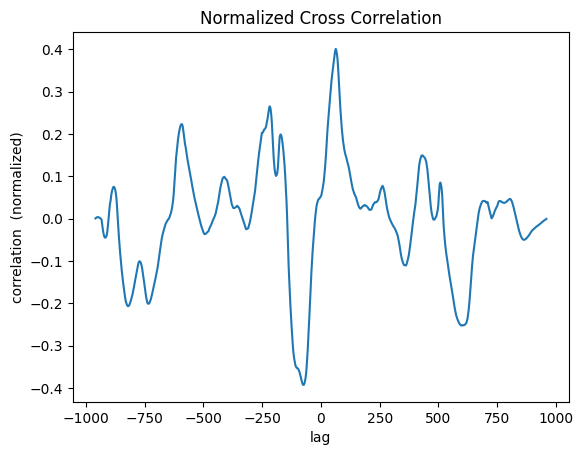

2022-10-04 23:47:00 has scint


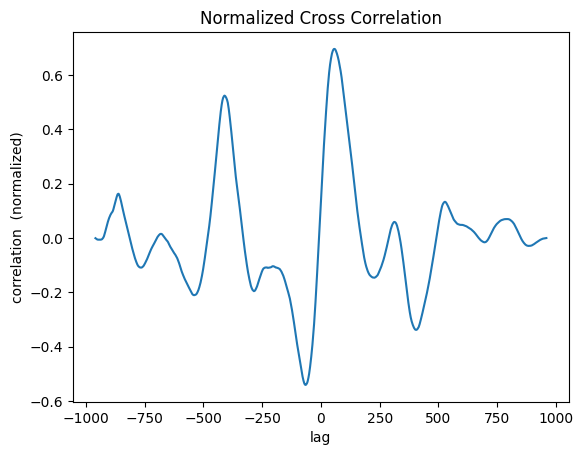

2022-10-04 23:48:00 has scint


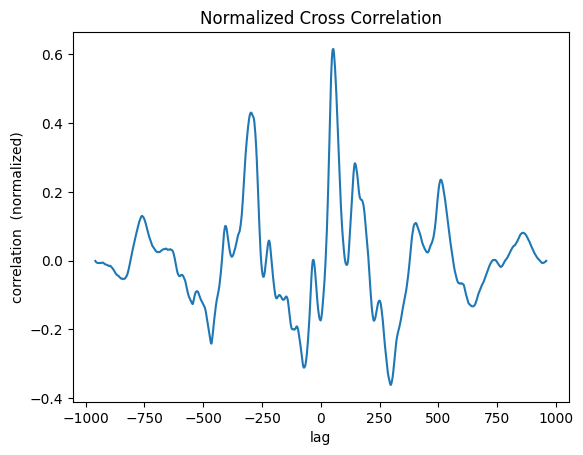

2022-10-04 23:49:00 has scint


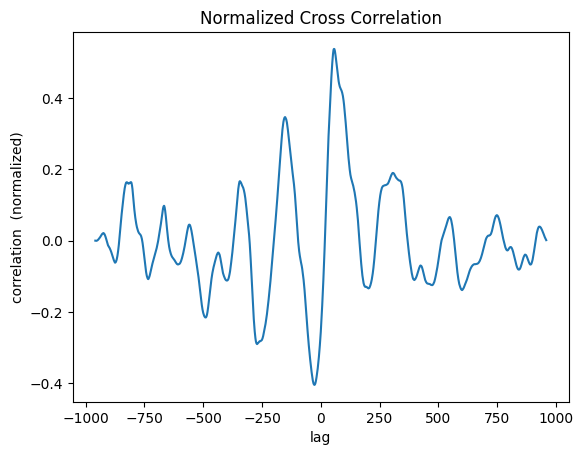

2022-10-04 23:50:00 has scint


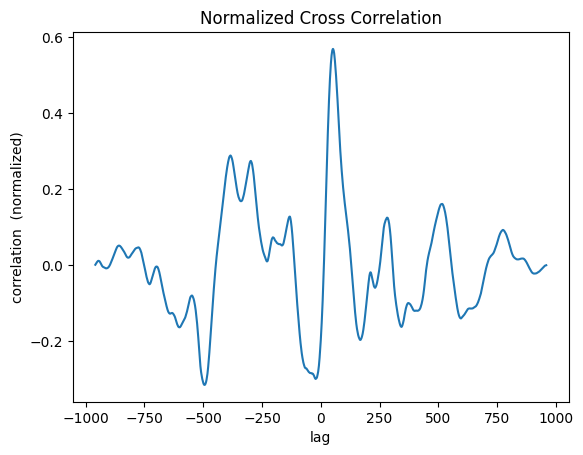

2022-10-04 23:51:00 has scint


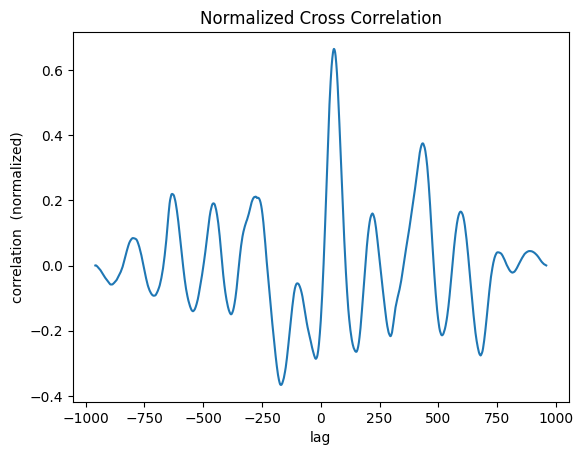

2022-10-04 23:52:00 has scint


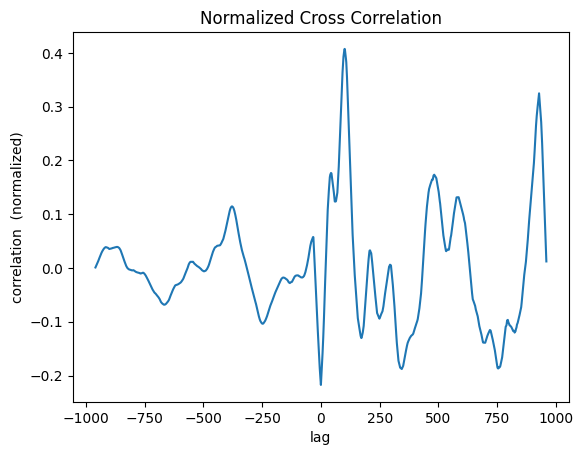

2022-10-04 23:53:00 has scint


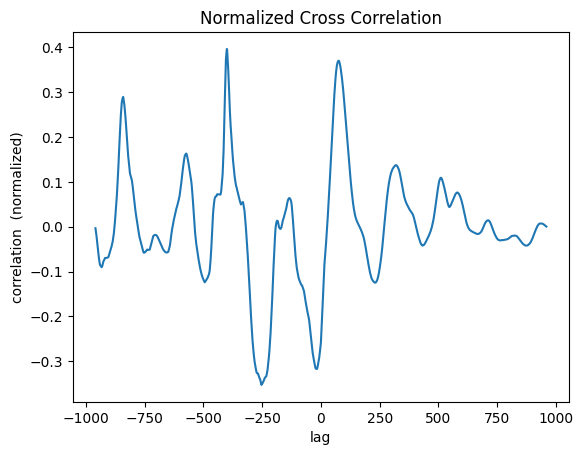

2022-10-04 23:54:00 has scint


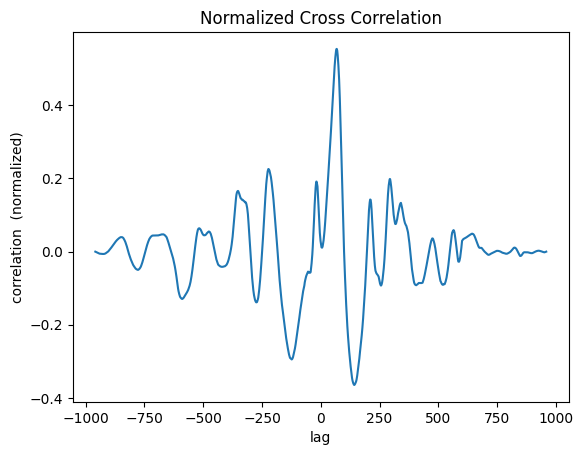

2022-10-04 23:55:00 has scint


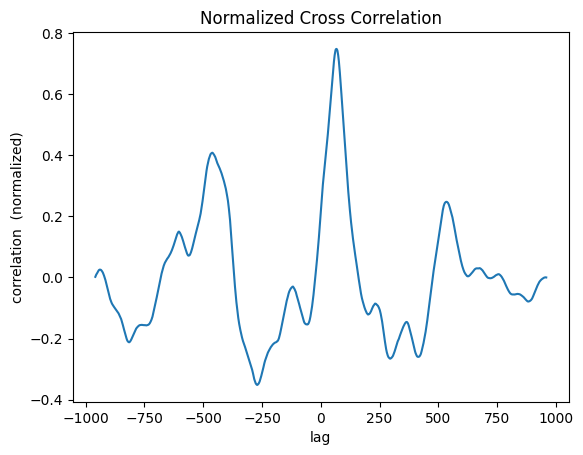

2022-10-04 23:56:00 has scint


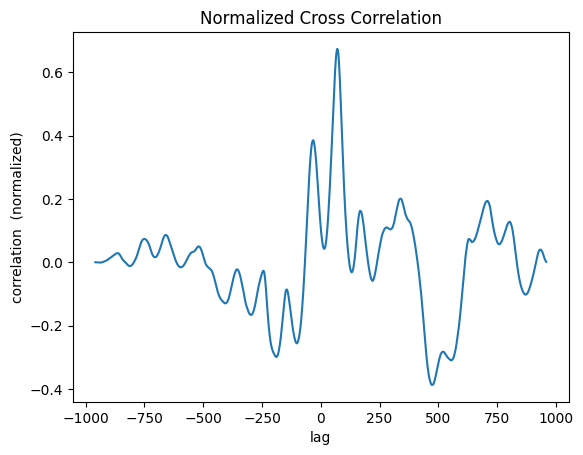

2022-10-04 23:57:00 has scint


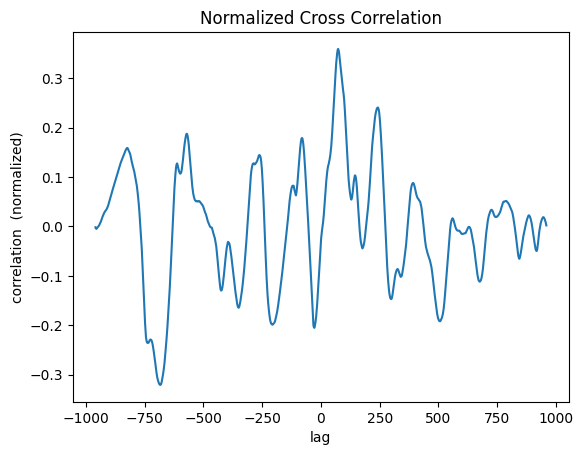

2022-10-04 23:58:00 has scint


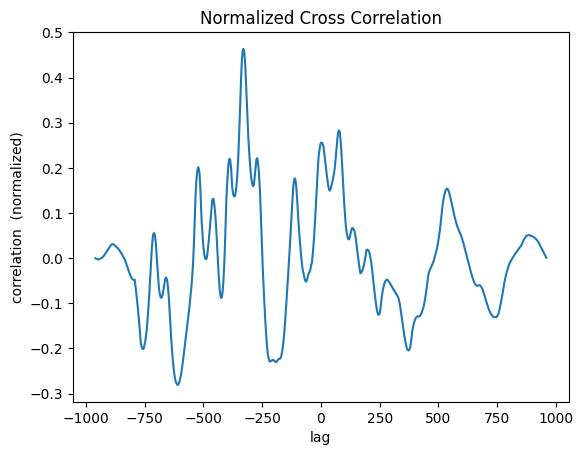

2022-10-04 23:59:00 has scint


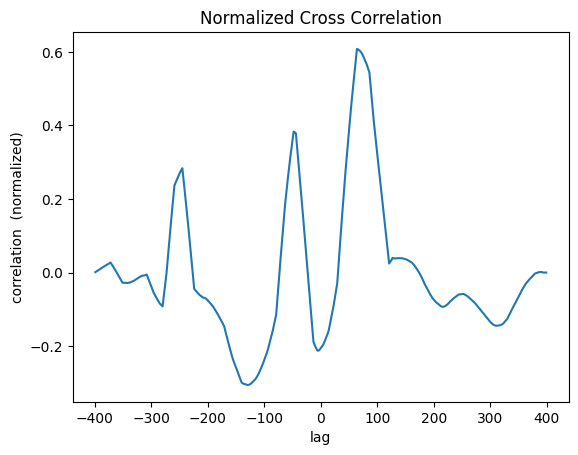

,minute,s4A,s4B,max corr,best_lag,time_delay
0,2022-10-04 20:00:00,0.109883,0.245625,0.111561,425,19.921875
1,2022-10-04 20:19:00,0.070515,0.201961,0.271832,89,4.171875
2,2022-10-04 20:23:00,0.790988,0.105811,0.243927,27,1.265625
3,2022-10-04 20:24:00,0.670399,0.084915,0.238690,99,4.640625
4,2022-10-04 20:25:00,0.778422,0.099772,0.261647,-231,-10.828125
...,...,...,...,...,...,...
75,2022-10-04 23:55:00,0.676954,0.515771,0.747849,67,3.140625
76,2022-10-04 23:56:00,0.910103,0.908810,0.673341,70,3.281250
77,2022-10-04 23:57:00,0.735396,1.019282,0.359487,73,3.421875
78,2022-10-04 23:58:00,1.028784,1.290675,0.463312,-330,-15.468750


Processed 80 scintillation events
Runtime: 6.225 seconds


In [10]:


start = time.time()


for min, group in min_groups:
    #print(f'Minute: {min}')
    sig_lina = db2lin(group['snr1_A'])
    s4a = np.std(sig_lina)/np.mean(sig_lina)
    sig_linb = db2lin(group['snr1_B'])
    s4b = np.std(sig_linb)/np.mean(sig_linb)
    #print(f's4 = {s4}')

    if s4a > thresh or s4b > thresh:
        print(f'{min} has scint')
        correlation, lag_b, cor_norm, lag_norm = cross_correlation(group["snr1_A"], group["snr1_B"])

        dt = group['time_sec'].diff().median()
        time_delay = lag_b * dt

        scint.append({
            'minute' : min,
            's4A' : s4a,
            's4B' : s4b,
            'max corr' : correlation,
            'best_lag' : lag_b,
            'time_delay': time_delay
            })
        
scintdf = pd.DataFrame(scint)
display(scintdf)

print(f"Processed {len(scintdf)} scintillation events")
print(f"Runtime: {time.time() - start:.3f} seconds")


In [13]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import importlib
from functions import cross_correlation
import time

start = time.time()

#import pqs
dfa = pd.read_parquet(r'C:\Users\irees\Downloads\Summer_learning\research26\Brazil_22_lvl0\scintpi3_20221004_2000_359060.7812W_72122.4141S_v325_lvl0.pq')
dfb = pd.read_parquet(r'C:\Users\irees\Downloads\Summer_learning\research26\Brazil_22_lvl0\scintpi3_20221004_2000_359072.7500W_72126.9375S_v325_lvl0.pq')

print(f"time to read files: {time.time() - start:.3f} seconds")

#filter dfs to contain certain elevation
dfa = dfa[dfa['elev'] > 20]
dfb = dfb[dfb['elev'] > 20]

#merge 2 reciever dfs
merged = dfa.merge(dfb, on=["datetime", "svid", 'cons'], suffixes=("_A", "_B"))
merged['snr_diff'] = abs(merged['snr1_A'] - merged['snr1_B']) #prob dont need this line


 #need to normalize time from datetime to just time in s
 #datetime to time
def datetime_to_seconds(df, time_column="datetime"):
    df = df.copy()
    # Seconds since first measurement
    df["time_sec"] = (
        df[time_column] - df[time_column].iloc[0] #simply measure change in time
    ).dt.total_seconds()
    return df

print(f"time to create new time: {time.time() - start:.3f} seconds")

#helps create s4
def db2lin(sig_db):
    return 10**(sig_db/10)

thresh = 0.2 #threshold for s4 scintillation measurement


########################

rstart = time.time()
scint = []
sat_groups = merged.groupby(['svid','cons'])

for (svid, cons), sat_group in sat_groups: #group the data into different satteltites 
    sat_group = datetime_to_seconds(sat_group)
    min_groups = sat_group.groupby(sat_group['datetime'].dt.floor('min')) #change this to group by sattelite

    for min, group in min_groups: #with the chosen satteltite for this itteration find s4 and then determine scintillation
        #print(f'Minute: {min}')
        sig_lina = db2lin(group['snr1_A'])
        s4a = np.std(sig_lina)/np.mean(sig_lina)
        sig_linb = db2lin(group['snr1_B'])
        s4b = np.std(sig_linb)/np.mean(sig_linb)
        #print(f's4 = {s4}')

        if s4a > thresh or s4b > thresh: #check threshold of scintillation and compute correlation
            #print(f'{min} has scint')
            correlation, lag_b, cor_norm, lag_norm = cross_correlation(group["snr1_A"], group["snr1_B"])

            if np.isnan(correlation):
                print(f"NaN correlation")
                print(f"Satellite: {svid}")
                print(f"Constellation: {cons}")
                print(f"Minute: {min}")

            dt = group['time_sec'].diff().median()
            time_delay = lag_b * dt

            scint.append({
                'svid' : svid,
                'cons' : cons,
                'minute' : min,
                's4A' : s4a,
                's4B' : s4b,
                'corr_norm' : cor_norm,
                'lag_norm' : lag_norm,
                'max_corr' : correlation,
                'best_lag' : lag_b,
                'time_delay': time_delay
                }) #create the dataframe that stores all the information regarding cross correlation of scintillation events

print(np.std(group["snr1_A"]))
print(np.std(group["snr1_B"]))
        
scintdf = pd.DataFrame(scint)
display(scintdf)

time to read files: 1.218 seconds
time to create new time: 5.931 seconds
NaN correlation
Satellite: 23
Constellation: 0
Minute: 2022-10-04 20:51:00
0.4761761753804993
0.39230090491866065


,svid,cons,minute,s4A,s4B,corr_norm,lag_norm,max_corr,best_lag,time_delay
0,2,2,2022-10-04 22:22:00,0.248260,0.246203,"[0.00023601625850355374, 0.0015509639844519247...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.724705,6,1.218750
1,2,2,2022-10-04 22:23:00,0.258300,0.282083,"[-1.7930009852308093e-05, -3.5860019704616186e...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.645983,6,1.218750
2,2,2,2022-10-04 22:24:00,0.356450,0.339789,"[-0.0006721788745185038, -0.001344357749037007...","[-476, -475, -474, -473, -472, -471, -470, -46...",0.811655,6,1.218750
3,2,2,2022-10-04 22:25:00,0.316135,0.314274,"[4.9965221128560714e-05, 9.993044225712143e-05...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.744665,6,1.218750
4,2,2,2022-10-04 22:26:00,0.345028,0.325862,"[-0.0001734960252106696, -0.000346992050421339...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.686357,7,1.421875
...,...,...,...,...,...,...,...,...,...,...
1541,136,1,2022-10-04 23:37:00,0.332755,0.340081,"[-0.0002986801244202465, -0.000597360248840493...","[-949, -948, -947, -946, -945, -944, -943, -94...",0.862867,18,0.843750
1542,136,1,2022-10-04 23:38:00,0.311478,0.274253,"[-0.001273931181367274, -0.002547862362734548,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.798184,18,0.843750
1543,136,1,2022-10-04 23:39:00,0.263936,0.258914,"[-0.000405569010462156, -0.000811138020924312,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.765527,16,0.750000
1544,136,1,2022-10-04 23:40:00,0.212937,0.179114,"[-0.0017825553229625494, -0.003565110645925099...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.589147,23,1.078125
